In [10]:
from importlib.metadata import version
import torch
import torch.nn as nn
from pathlib import Path
#from .previous_chapters import MultiHeadAttention 

PATH_VECS = Path('../datasets/context_vecs.pt')

context_vecs = torch.load(PATH_VECS)

#print(context_vecs[:10])

Vektoren plotten

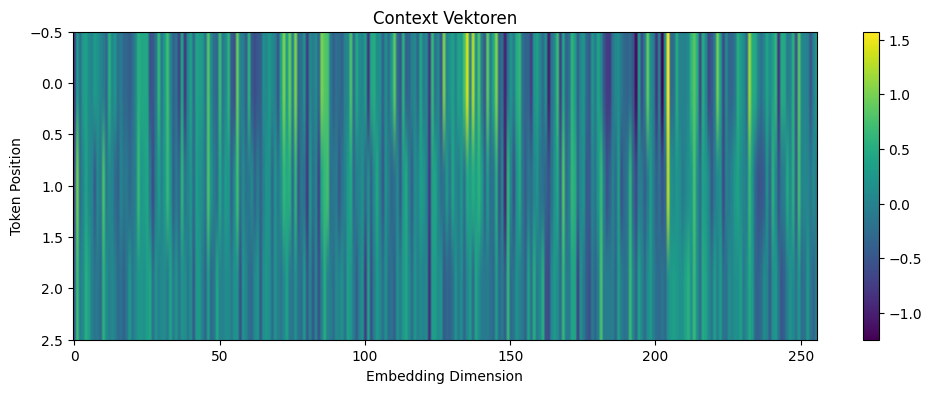

In [11]:
import matplotlib.pyplot as plt

vector_in_array = context_vecs[0].detach().numpy()
#print(vector_in_array.shape)
#print(vector_in_array)

if __name__ == '__main__':

    plt.figure(figsize=(12,4))
    plt.imshow(vector_in_array, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("Context Vektoren")
    plt.xlabel("Embedding Dimension")
    plt.ylabel("Token Position")
    plt.show()


Erstellung einer Konfigurationsdictionary für das GPT-Modell. Durch die Erstellung dieses Dictionaries müssen die Werte
wie die Embeddings Größen nur einmal definiert werden.

vocab_size ist die Anzahl der Tokens die der Tokenizer kennt. 
context_length ist die maximale Anzahl die das Modell gleichzeitig lesen kann. (GPT-2 wirde mit dieser Anzahl trainiert.)
emb_dim, somit wird jedes Token als Vektor mit 768 Zahlen dargestellt.(Zahlen beschreiben die Bedeutung des Tokens, gleicher Grund wie oben)
n_heads ist die Anzahl des Attention-Heads. (Head schaut sich den Text aus anderen Blickwinkeln an; 768 ÷ 12 = 64 -> 64 Dimensionen)
n_layer ist die Anzahl der Transformer Blöcke hintereinander
drop_rate, somit werden 10% der Verbindungen im Training zufällig ausgeschaltet.
qkv_bias, es existiert kein zusätzlicher Bias Parameter in der Attention.

In [12]:
GPT_CONFIG = {
    "vocab_size": 100277,       # cl100k_base Vokabulargröße
    "context_length": 1024,     # maximale Sequenzlänge
    "emb_dim": 768,             # Embedding Dimension
    "n_heads": 12,              # Anzahl Attention Heads
    "n_layers": 12,             # Anzahl TransformerBlocks
    "drop_rate": 0.1,           # Dropout Rate
    "qkv_bias": False           # kein Bias in Attention
}

Implementierung der LayerNorm Klasse zur Normalisierung der Aktivierungen.
Nach der Attention können die Zahlen sehr groß oder sehr klein werden, 
was das Training instabil macht. LayerNorm bringt alle Zahlen zurück 
in einen normalen Bereich (Mittelwert 0, Varianz 1).

eps verhindert dass durch 0 geteilt wird.
scale und shift sind lernbare Parameter die während dem Training 
angepasst werden um die beste Normalisierung für die Daten zu finden.

In [13]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

Implementierung der GELU Aktivierungsfunktion (Gaussian Error Linear Unit).
Aktivierungsfunktionen werden benötigt damit das Modell nicht-lineare 
Zusammenhänge lernen kann. Ohne Aktivierungsfunktion wäre das Modell 
nur eine einfache lineare Gleichung egal wie viele Schichten es hat.

Im Vergleich zu ReLU (Rectified Linear Unit) die negative Werte einfach 
auf 0 setzt, dämpft GELU negative Werte sanft. Das führt zu einem 
stabileren Training und besseren Ergebnissen bei Sprachmodellen.
GPT-2 wurde mit GELU trainiert weshalb wir es hier ebenfalls verwenden.

In [14]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

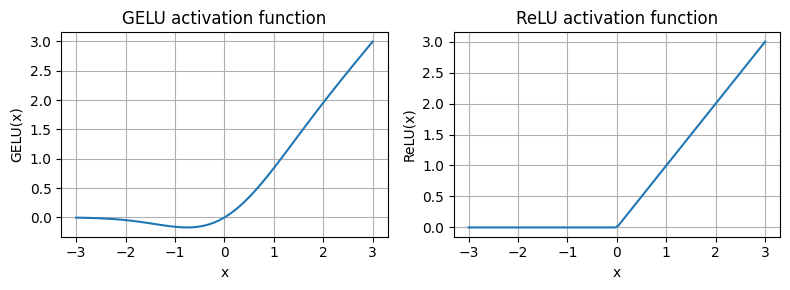

In [15]:

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

if __name__ == '__main__':

    plt.figure(figsize=(8, 3))
    for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
        plt.subplot(1, 2, i)
        plt.plot(x, y)
        plt.title(f"{label} activation function")
        plt.xlabel("x")
        plt.ylabel(f"{label}(x)")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

Implementierung der FeedForward Klasse.
Nach der Attention wird jedes Token einzeln durch ein kleines 
neuronales Netz geschickt. Dies gibt dem Modell mehr Kapazität 
um komplexe Muster zu lernen.

Die erste Linear Schicht weitet die Dimension von 768 auf 3072 auf 
(4 × emb_dim). Dieser größere Zwischenraum gibt dem Modell mehr 
"Platz zum Denken". Danach wird GELU als Aktivierungsfunktion angewendet.
Die zweite Linear Schicht reduziert die Dimension wieder zurück auf 768.

In [16]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)



Implementierung des TransformerBlocks. 
Der TransformerBlock ist das Herzstück des Modells und kombiniert 
alle bisherigen Bausteine. Er wird 12 mal hintereinander ausgeführt,
wobei jeder Durchlauf das Verständnis des Textes vertieft.

Der Block besteht aus zwei Teilen:
Im ersten Teil wird LayerNorm angewendet, dann MultiHeadAttention 
aus Lab 3 und anschließend Dropout.
Im zweiten Teil wird erneut LayerNorm angewendet, dann FeedForward
und anschließend Dropout.

Nach jedem Teil wird der ursprüngliche Input wieder draufaddiert (Shortcut).
Der Shortcut verhindert dass Informationen verloren gehen wenn das 
Netz tiefer wird (Vanishing Gradient Problem).

In [17]:
#sys.path.append('../ch04/01_main-chapter-code/')
import sys
sys.path.append('../ch04/01_main-chapter-code')
from previous_chapters import MultiHeadAttention  # pyright: ignore[reportMissingImports]

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

Implementierung des GPTModel.
Das GPTModel ist das vollständige Sprachmodell und steckt alle 
bisherigen Bausteine zusammen.

tok_emb wandelt die Token IDs in Vektoren um (Lookup-Tabelle aus Lab 2).
pos_emb fügt die Positionsinformation hinzu damit das Modell die 
Reihenfolge der Tokens kennt (ebenfalls aus Lab 2).
Beide Embeddings werden addiert und durch Dropout geschickt.
Danach werden die Daten durch 12 TransformerBlöcke geschickt.
Am Ende wird LayerNorm angewendet und die finale Linear Schicht 
gibt für jedes Token eine Wahrscheinlichkeit über das gesamte 
Vokabular aus (100277 Werte). Der höchste Wert ist das 
wahrscheinlichste nächste Token.

In [18]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

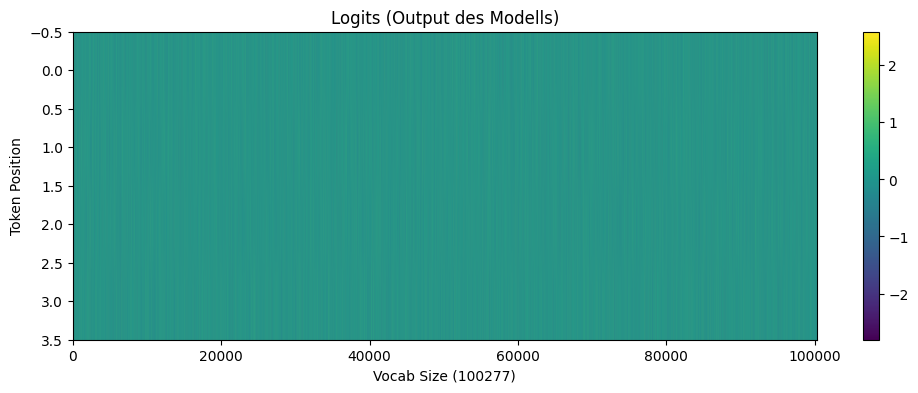

In [20]:
# So funktioniert es - Token IDs erstellen
import tiktoken
tokenizer = tiktoken.get_encoding("cl100k_base")

start_context = "Recepie:"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # [1, seq_len]

model = GPTModel(GPT_CONFIG)
model.eval()

with torch.no_grad():
    output = model(encoded_tensor)

if __name__ == '__main__':

    plt.figure(figsize=(12, 4))
    plt.imshow(output[0].detach().numpy(), aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("Logits (Output des Modells)")
    plt.xlabel("Vocab Size (100277)")
    plt.ylabel("Token Position")
    plt.show()

Implementierung der generate_text_simple Funktion.
Diese Funktion generiert Text indem sie Token für Token das 
wahrscheinlichste nächste Wort auswählt (Greedy Decoding).

idx ist der Eingabetext als Token IDs.
max_new_tokens ist die Anzahl der zu generierenden Tokens.
context_size ist die maximale Anzahl an Tokens die das Modell 
gleichzeitig sehen kann (1024).

In jedem Schritt wird der Eingabetext auf die letzten 1024 Tokens 
gekürzt falls er länger ist. Dann wird das Modell gefragt welches 
Token als nächstes kommt. Das Token mit der höchsten Wahrscheinlichkeit 
wird ausgewählt und an den bisherigen Text angehängt.
Da wir nur vorhersagen und nicht trainieren wird torch.no_grad() 
verwendet um Rechenzeit zu sparen.
Das Modell ist untrainiert weshalb der generierte Text noch 
keinen Sinn ergibt.

In [21]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [22]:
import os
os.makedirs('../../datasets', exist_ok=True)

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG)

torch.save(model.state_dict(), '../../datasets/model.pt')